## How are in-demand skills trending for Data Engineers?

#### Methology
1. Aggregate skill counts monthly
2. Re-analyze based on percentage of total jobs
3. Plot the monthly skill demand

In [19]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from matplotlib import cm
import ast
import seaborn as sns

# Loading Data
df = pd.read_csv('C:/Users/david/Desktop/job_postings_flat.csv')

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

# Filter
df = df[df['job_posted_date'].dt.year == 2024]

In [20]:
df_DE_Ger = df[(df['job_title_short'] == 'Data Engineer') & (df['job_country'] == 'Germany')].copy()

In [21]:
df_DE_Ger['job_posted_month_no'] = df_DE_Ger['job_posted_date'].dt.month

In [22]:
df_DE_Ger_explode = df_DE_Ger.explode('job_skills')

In [23]:
df_DE_Ger_pivot = df_DE_Ger_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

df_DE_Ger_pivot.loc['Total'] = df_DE_Ger_pivot.sum()

df_DE_Ger_pivot = df_DE_Ger_pivot[df_DE_Ger_pivot.loc['Total'].sort_values(ascending=False).index]

df_DE_Ger_pivot = df_DE_Ger_pivot.drop('Total')

df_DE_Ger_pivot

job_skills,python,sql,azure,aws,java,spark,databricks,kafka,power bi,scala,...,vb.net,electron,elixir,unify,nuix,nltk,fortran,mongo,ruby on rails,sass
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,258,270,195,137,115,97,65,62,52,65,...,0,0,0,0,0,0,0,0,0,0
2,324,292,209,155,122,97,65,78,56,52,...,1,0,0,0,0,0,1,0,0,0
3,266,267,180,117,97,76,68,46,60,45,...,0,1,0,0,1,0,0,0,1,0
4,244,230,141,108,86,74,59,36,38,32,...,0,0,0,0,0,1,0,1,0,0
5,240,220,141,114,93,71,53,47,40,42,...,0,0,0,1,0,0,0,0,0,0
6,261,231,156,123,98,94,53,57,46,48,...,0,0,0,0,0,0,0,0,0,1
7,318,283,181,120,109,118,81,61,53,68,...,0,0,1,0,0,0,0,0,0,0
8,168,146,130,53,86,117,57,53,62,33,...,0,0,0,0,0,0,0,0,0,0
9,90,87,69,25,47,68,24,25,44,22,...,0,0,0,0,0,0,0,0,0,0


In [24]:
df_DE_Ger_totals = df_DE_Ger.groupby('job_posted_month_no').size()

df_DE_Ger_percentage = df_DE_Ger_pivot.div(df_DE_Ger_totals/100, axis=0)

df_DE_Ger_percentage = df_DE_Ger_percentage.reset_index()
df_DE_Ger_percentage['job_posted_month'] = df_DE_Ger_percentage['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DE_Ger_percentage = df_DE_Ger_percentage.drop('job_posted_month_no', axis=1)
df_DE_Ger_percentage = df_DE_Ger_percentage.set_index('job_posted_month')

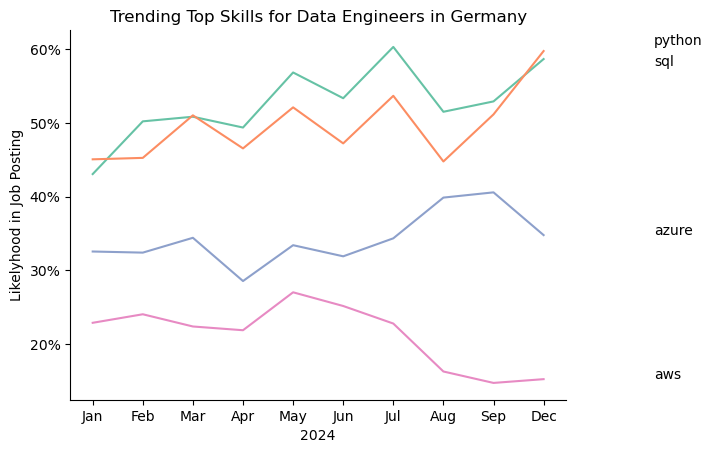

In [27]:
from matplotlib.ticker import PercentFormatter

df_plot = df_DE_Ger_percentage.iloc[:,:4]
sns.lineplot(df_plot, dashes=False, palette='Set2')
plt.title('Trending Top Skills for Data Engineers in Germany')
plt.ylabel('Likelyhood in Job Posting')
plt.xlabel('2024')
plt.legend().remove()
sns.despine()

ax=plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i in range(4):
    col = df_plot.columns[i]
    y = df_plot.iloc[-1, i]

    if col.lower() == "python":
        y = y + 2
    elif col.lower() == "sql":
        y = y - 2

    plt.text(11.2, y, col)

